<a href="https://colab.research.google.com/github/JADASIMONESIMON/-Hooplytics-complex-messy-data-project/blob/main/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import tools
import requests
import pandas as pd
import numpy as np

In [2]:
#API Key
API_KEY = "11f847a9-8965-4f08-8239-98b98e34e2f8"


In [3]:
#calling API Key
url = "https://api.balldontlie.io/v1/players"  # go back to this for now

headers = {
    "Authorization": API_KEY
}

params = {
    "season": 2024,
    "season_type": "regular",
    "type": "base",
    "per_page": 100
}

In [4]:
response = requests.get(url, headers=headers, params=params)

print("Status:", response.status_code)
print("Text preview:", response.text[:300])

data = response.json()
df_2024 = pd.json_normalize(data["data"])
df_2024.head()

Status: 200
Text preview: {"data":[{"id":1,"first_name":"Alex","last_name":"Abrines","position":"G","height":"6-6","weight":"190","jersey_number":"8","college":"FC Barcelona","country":"Spain","draft_year":2013,"draft_round":2,"draft_number":32,"team":{"id":21,"conference":"West","division":"Northwest","city":"Oklahoma City"


,id,first_name,last_name,position,height,weight,jersey_number,college,country,draft_year,draft_round,draft_number,team.id,team.conference,team.division,team.city,team.name,team.full_name,team.abbreviation
0,1,Alex,Abrines,G,6-6,190,8,FC Barcelona,Spain,2013.0,2.0,32.0,21,West,Northwest,Oklahoma City,Thunder,Oklahoma City Thunder,OKC
1,2,Jaylen,Adams,G,6-0,225,10,St. Bonaventure,USA,NaN,NaN,NaN,1,East,Southeast,Atlanta,Hawks,Atlanta Hawks,ATL
2,3,Steven,Adams,C,6-11,265,12,Pittsburgh,New Zealand,2013.0,1.0,12.0,11,West,Southwest,Houston,Rockets,Houston Rockets,HOU
3,4,Bam,Adebayo,C-F,6-9,255,13,Kentucky,USA,2017.0,1.0,14.0,16,East,Southeast,Miami,Heat,Miami Heat,MIA
4,5,DeVaughn,Akoon-Purcell,G-F,6-5,201,44,Illinois State,Trinidad and Tobago,2016.0,NaN,NaN,8,West,Northwest,Denver,Nuggets,Denver Nuggets,DEN


In [5]:
# TASK 1: Clean data (Avnoor)

# - Handle missing values
df_2024 = df_2024.fillna(0)

# - Convert columns to numeric
numeric_cols = ["height_feet", "height_inches", "weight_pounds"]
for col in numeric_cols:
    if col in df_2024.columns:
        df_2024[col] = pd.to_numeric(df_2024[col], errors='coerce')

# - Rename columns
df_2024 = df_2024.rename(columns={
    "first_name": "FirstName",
    "last_name": "LastName",
    "height_feet": "HeightFeet",
    "height_inches": "HeightInches",
    "weight_pounds": "Weight"
})

# - Remove bad rows (duplicates)
df_2024 = df_2024.drop_duplicates()

# Final output
df_2024.head()


,id,FirstName,LastName,position,height,weight,jersey_number,college,country,draft_year,draft_round,draft_number,team.id,team.conference,team.division,team.city,team.name,team.full_name,team.abbreviation
0,1,Alex,Abrines,G,6-6,190,8,FC Barcelona,Spain,2013.0,2.0,32.0,21,West,Northwest,Oklahoma City,Thunder,Oklahoma City Thunder,OKC
1,2,Jaylen,Adams,G,6-0,225,10,St. Bonaventure,USA,0.0,0.0,0.0,1,East,Southeast,Atlanta,Hawks,Atlanta Hawks,ATL
2,3,Steven,Adams,C,6-11,265,12,Pittsburgh,New Zealand,2013.0,1.0,12.0,11,West,Southwest,Houston,Rockets,Houston Rockets,HOU
3,4,Bam,Adebayo,C-F,6-9,255,13,Kentucky,USA,2017.0,1.0,14.0,16,East,Southeast,Miami,Heat,Miami Heat,MIA
4,5,DeVaughn,Akoon-Purcell,G-F,6-5,201,44,Illinois State,Trinidad and Tobago,2016.0,0.0,0.0,8,West,Northwest,Denver,Nuggets,Denver Nuggets,DEN


In [6]:
# TASK 2: Feature Engineering (Jada)

import pandas as pd

# -----------------------------
# Step 1: Load the raw totals data
# -----------------------------
df = pd.read_csv("nba_2024_totals.csv")


# -----------------------------
# Step 2: Data Cleaning
# -----------------------------

# Check dataset info
print("\nDataset info before cleaning:")
print(df.info())

# Check for missing values
print("\nMissing values in each column:")
print(df.isna().sum())

# Drop rows with missing values
df = df.dropna()

# Remove duplicate rows if any
df = df.drop_duplicates()

# Convert important stat columns to numeric just in case
stat_cols = ['PTS', 'FG', 'FGA', '3P', '3PA']
for col in stat_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check again for missing values after numeric conversion
print("\nMissing values after numeric conversion:")
print(df[stat_cols].isna().sum())

# Drop rows that became invalid after conversion
df = df.dropna(subset=stat_cols)

# Reset index after cleaning
df = df.reset_index(drop=True)

print("\nShape after cleaning:")
print(df.shape)

print("\nCleaned dataset preview:")
print(df.head())

# -----------------------------
# Step 3: Create league totals from player data
# -----------------------------
totals = df[stat_cols].sum()

# Build a single-row dataframe for the 2024 season
df_league = pd.DataFrame({
    'Season': [2024],
    'PTS': [totals['PTS']],
    'FG': [totals['FG']],
    'FGA': [totals['FGA']],
    '3P': [totals['3P']],
    '3PA': [totals['3PA']]
})

# -----------------------------
# Step 5: Descriptive Statistics
# -----------------------------

# Basic statistics
print("\nBasic Statistics:")
print(df[stat_cols].describe())

# Mean
print("\nMean:")
print(df[stat_cols].mean())

# Median
print("\nMedian:")
print(df[stat_cols].median())

# Mode
print("\nMode:")
print(df[stat_cols].mode().iloc[0])

# Sum
print("\nSum:")
print(df[stat_cols].sum())

# Range
print("\nRange:")
print(df[stat_cols].max() - df[stat_cols].min())

# Variance
print("\nVariance:")
print(df[stat_cols].var())

# Standard Deviation
print("\nStandard Deviation:")
print(df[stat_cols].std())

# Quartiles
print("\nQuartiles:")
print(df[stat_cols].quantile([0.25, 0.5, 0.75]))


Dataset info before cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 735 non-null    float64
 1   Player             736 non-null    object 
 2   Age                735 non-null    float64
 3   Team               735 non-null    object 
 4   Pos                735 non-null    object 
 5   G                  735 non-null    float64
 6   GS                 735 non-null    float64
 7   MP                 735 non-null    float64
 8   FG                 735 non-null    float64
 9   FGA                735 non-null    float64
 10  FG%                728 non-null    float64
 11  3P                 735 non-null    float64
 12  3PA                735 non-null    float64
 13  3P%                690 non-null    float64
 14  2P                 735 non-null    float64
 15  2PA                735 non-null    float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# TASK 3: Analysis (Bennett)
seasons = ['2024', '2025', '2026']
all_total = []

for year in seasons:
  url = f"https://www.basketball-reference.com/leagues/NBA_{year}_totals.html"
  tables = pd.read_html(url)

  for i, table in enumerate(tables):
      if 'PTS' in table.columns and len(table) > 20:
          df = table
          break
  else:
      print(f"No table found for {year}")
      continue

  cols = [col for col in ['PTS', '3P','3PA','FG','FGA'] if col in df.columns]
  totals = df[cols].sum(numeric_only=True).round(0)
  totals['Season'] = year
  all_total.append(totals)

# - Sum league totals
df_league = pd.DataFrame(all_total)
pts = df_league['PTS'].sum()
three_pt = df_league.get('3P', pd.Series([0])).sum()
three_pa = df_league.get('3PA', pd.Series([0])).sum()
fg = df_league.get('FG', pd.Series([0])).sum()
fga = df_league.get('FGA', pd.Series([0])).sum()

print(f"\nLeague Totals (2024-2026)")
print(f"Total Points: {pts:,.0f}")
print(f"Three Pointers Made / Attempted: {three_pt:,.0f}/{three_pa:,.0f}")
print(f"Field Goals Made / Attempted: {fg:,.0f}/{fga:,.0f}")

# - Calculate overall percentages
if three_pa > 0:
    three_pct = (three_pt / three_pa * 100).round(1)
else:
    three_pct = 0
if fga > 0:
    fg_pct = (fg / fga * 100).round(1)
else:
    fg_pct = 0

print(f"\nOverall Percentages")
print(f"League Three Pointers: {three_pct}%")
print(f"League Field Goals: {fg_pct}%")

# - Compare 3PT vs 2PT
print(f"\n3PT vs 2PT")
print(f"3PT are {three_pa / fga * 100:,.1f}% of FGA")

# - Loop through multiple seasons
print(f"\nSeasons")
print(df_league[['Season','PTS']].round(0))


League Totals (2024-2026)
Total Points: 936,600
Three Pointers Made / Attempted: 108,570/300,735
Field Goals Made / Attempted: 342,791/730,267

Overall Percentages
League Three Pointers: 36.1%
League Field Goals: 46.9%

3PT vs 2PT
3PT are 41.2% of FGA

Seasons
  Season       PTS
0   2024  310834.0
1   2025  311448.0
2   2026  314318.0


Season summary:
   Season       PTS       FGA       3PA     TwoPA  ThreePtShare  TwoPtShare
0  2024.0  310834.0  243062.0   96891.0  146171.0         39.86       60.14
1  2025.0  311448.0  244343.0  102371.0  141972.0         41.90       58.10
2  2026.0  314318.0  242862.0  101473.0  141389.0         41.78       58.22


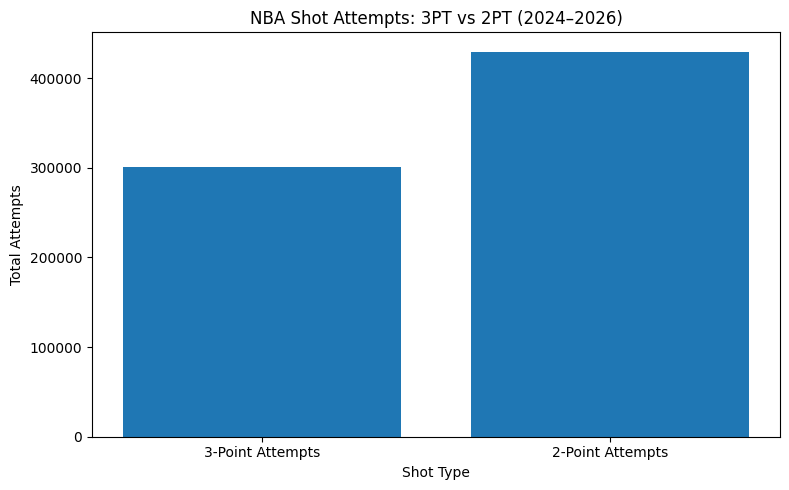

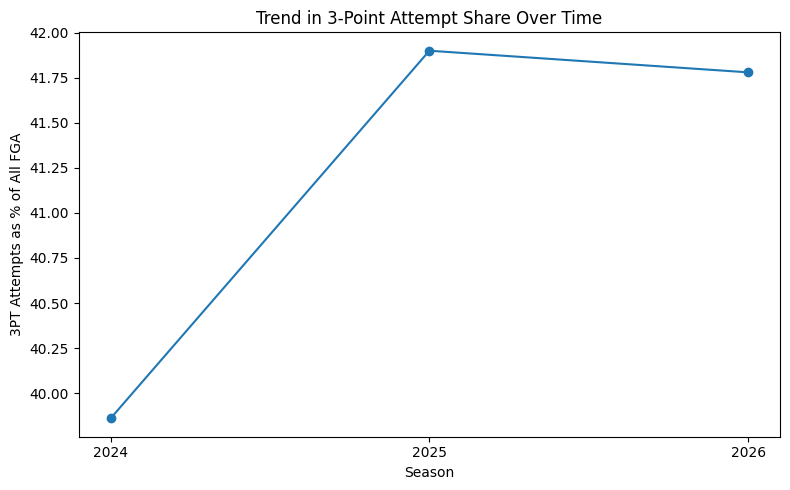

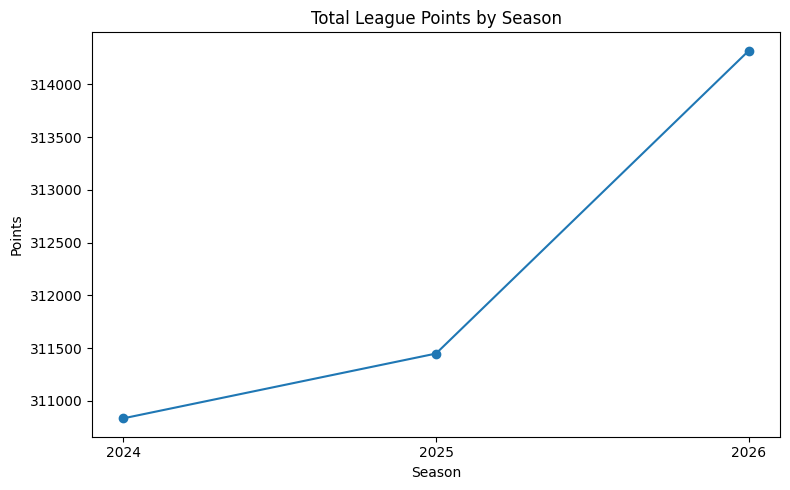

In [8]:
# TASK 4: Visualization + Presentation (Alyssa)

import matplotlib.pyplot as plt

# --- Rebuild season-by-season totals cleanly ---
seasons = ['2024', '2025', '2026']
all_total = []

for year in seasons:
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}_totals.html"
    tables = pd.read_html(url)

    df = None
    for table in tables:
        if 'PTS' in table.columns and len(table) > 20:
            df = table.copy()
            break

    if df is None:
        print(f"No table found for {year}")
        continue

    # Keep only needed numeric columns
    cols = [col for col in ['PTS', '3P', '3PA', 'FG', 'FGA'] if col in df.columns]
    season_totals = df[cols].sum(numeric_only=True)
    season_totals['Season'] = int(year)
    all_total.append(season_totals)

# Create season summary dataframe
df_league = pd.DataFrame(all_total)

# Feature engineering for visualization
df_league['TwoPA'] = df_league['FGA'] - df_league['3PA']
df_league['ThreePtShare'] = (df_league['3PA'] / df_league['FGA']) * 100
df_league['TwoPtShare'] = (df_league['TwoPA'] / df_league['FGA']) * 100
df_league['FGPercent'] = (df_league['FG'] / df_league['FGA']) * 100
df_league['ThreePtPercent'] = (df_league['3P'] / df_league['3PA']) * 100

df_league = df_league.round(2)

print("Season summary:")
print(df_league[['Season', 'PTS', 'FGA', '3PA', 'TwoPA', 'ThreePtShare', 'TwoPtShare']])

# --- Chart 1: Bar chart for overall 3PT vs 2PT attempts ---
total_3pa = df_league['3PA'].sum()
total_2pa = df_league['TwoPA'].sum()

plt.figure(figsize=(8,5))
plt.bar(['3-Point Attempts', '2-Point Attempts'], [total_3pa, total_2pa])
plt.title('NBA Shot Attempts: 3PT vs 2PT (2024–2026)')
plt.ylabel('Total Attempts')
plt.xlabel('Shot Type')
plt.tight_layout()
plt.show()

# --- Chart 2: Trend line over time for 3PT shot share ---
plt.figure(figsize=(8,5))
plt.plot(df_league['Season'], df_league['ThreePtShare'], marker='o')
plt.title('Trend in 3-Point Attempt Share Over Time')
plt.xlabel('Season')
plt.ylabel('3PT Attempts as % of All FGA')
plt.xticks(df_league['Season'])
plt.tight_layout()
plt.show()

# --- Optional Chart 3: Points by season ---
plt.figure(figsize=(8,5))
plt.plot(df_league['Season'], df_league['PTS'], marker='o')
plt.title('Total League Points by Season')
plt.xlabel('Season')
plt.ylabel('Points')
plt.xticks(df_league['Season'])
plt.tight_layout()
plt.show()

Explanation (Alyssa)
This visualization compares how NBA teams attempt 3-point shots versus 2-point shots across the 2024–2026 seasons. The bar chart shows the total volume of each shot type, while the trend line shows how the share of 3-point attempts changes over time.

The results suggest that 3-point shooting makes up a large portion of total field goal attempts, which reflects how modern NBA offenses rely more heavily on spacing and perimeter shooting. Even though 2-point attempts still account for a larger total share, the trend line helps show whether teams are continuing to increase their dependence on the three-point shot each season.

These visuals support the project goal by turning cleaned basketball data into an easy to understand summary of league wide scoring behavior.

In [9]:
#Clean and preprocess your data (handle missing values, outliers, formatting, etc.). (Avnoor)


# 1. HANDLE MISSING VALUES

df_2024 = df_2024.replace("", np.nan)

# Filling numeric columns with median
numeric_cols = ["weight", "draft_year", "draft_round", "draft_number"]

for col in numeric_cols:
    if col in df_2024.columns:
        df_2024[col] = pd.to_numeric(df_2024[col], errors='coerce')
        df_2024[col] = df_2024[col].fillna(df_2024[col].median())

# Filling categorical columns
df_2024["position"] = df_2024["position"].fillna("Unknown")
df_2024["college"] = df_2024["college"].fillna("Unknown")
df_2024["country"] = df_2024["country"].fillna("Unknown")


# 2. Splitting the height column to feet and inches
# Convert "6-6" → feet + inches
df_2024[["HeightFeet", "HeightInches"]] = df_2024["height"].str.split("-", expand=True)

df_2024["HeightFeet"] = pd.to_numeric(df_2024["HeightFeet"], errors='coerce')
df_2024["HeightInches"] = pd.to_numeric(df_2024["HeightInches"], errors='coerce')


# Filling missing height values
df_2024["HeightFeet"] = df_2024["HeightFeet"].fillna(df_2024["HeightFeet"].median())
df_2024["HeightInches"] = df_2024["HeightInches"].fillna(df_2024["HeightInches"].median())

# Total height
df_2024["HeightTotal"] = df_2024["HeightFeet"] * 12 + df_2024["HeightInches"]


# 3. Renaming Columns
df_2024 = df_2024.rename(columns={
    "FirstName": "FirstName",
    "LastName": "LastName",
    "weight": "Weight",
    "position": "Position",
    "team.full_name": "Team"
})


# 4. BMI calculation
df_2024["BMI"] = (df_2024["Weight"] / (df_2024["HeightTotal"] ** 2)) * 703


# 5. Removing Duplicates
df_2024 = df_2024.drop_duplicates()


# 6. Handling Outliers (IQR)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

for col in ["HeightTotal", "Weight", "BMI"]:
    df_2024 = remove_outliers(df_2024, col)


# 7. Cleaning text formatting
df_2024["FirstName"] = df_2024["FirstName"].str.strip().str.title()
df_2024["LastName"] = df_2024["LastName"].str.strip().str.title()
df_2024["Position"] = df_2024["Position"].str.upper()


# 8. Resetting the index
df_2024 = df_2024.reset_index(drop=True)


# After checking I decided to continue cleaning

# 1. dropping redundant columns
df_2024 = df_2024.drop(columns=["height"])


# 2. Cleaning position values
df_2024["Position"] = df_2024["Position"].replace({
    "G-F": "G",
    "F-G": "F",
    "C-F": "C",
    "F-C": "F"
})


# 3. Handling Draft data properly
df_2024["draft_year"] = df_2024["draft_year"].replace(0, np.nan)
df_2024["draft_round"] = df_2024["draft_round"].replace(0, np.nan)
df_2024["draft_number"] = df_2024["draft_number"].replace(0, np.nan)


# Final output
df_2024.head()

,id,FirstName,LastName,Position,Weight,jersey_number,college,country,draft_year,draft_round,...,team.conference,team.division,team.city,team.name,Team,team.abbreviation,HeightFeet,HeightInches,HeightTotal,BMI
0,1,Alex,Abrines,G,190,8,FC Barcelona,Spain,2013.0,2.0,...,West,Northwest,Oklahoma City,Thunder,Oklahoma City Thunder,OKC,6,6,78,21.954306
1,3,Steven,Adams,C,265,12,Pittsburgh,New Zealand,2013.0,1.0,...,West,Southwest,Houston,Rockets,Houston Rockets,HOU,6,11,83,27.042386
2,4,Bam,Adebayo,C,255,13,Kentucky,USA,2017.0,1.0,...,East,Southeast,Miami,Heat,Miami Heat,MIA,6,9,81,27.322817
3,5,Devaughn,Akoon-Purcell,G,201,44,Illinois State,Trinidad and Tobago,2016.0,NaN,...,West,Northwest,Denver,Nuggets,Denver Nuggets,DEN,6,5,77,23.832518
4,6,Lamarcus,Aldridge,F,250,21,University of Texas at Austin,USA,2006.0,1.0,...,East,Atlantic,Brooklyn,Nets,Brooklyn Nets,BKN,6,11,83,25.511685


Descriptive Statistics:
           PTS  PTS_per_game  FG_pct  ThreePT_pct  ThreePA_share  AST_to_TOV  \
count   735.00        735.00  727.00       689.00         727.00      700.00   
mean    422.90          8.02   44.75        31.69          41.09      214.72   
std     475.81          6.48   11.07        13.72          22.57      144.19   
min       0.00          0.00    0.00         0.00           0.00        0.00   
25%      51.50          3.37   40.00        28.05          27.57      133.33   
50%     244.00          6.14   44.65        34.59          41.57      189.18   
75%     624.50         11.05   50.00        38.52          55.84      258.70   
max    2370.00         34.69   80.00       100.00         100.00     1233.33   

       Reb_per_game  
count        735.00  
mean           3.24  
std            2.32  
min            0.00  
25%            1.56  
50%            2.81  
75%            4.34  
max           13.66  

Top 10 Scorers:
                    Player Team     PTS 

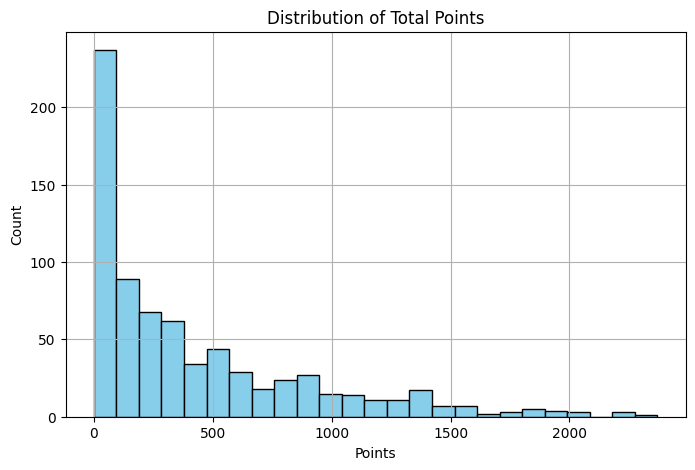

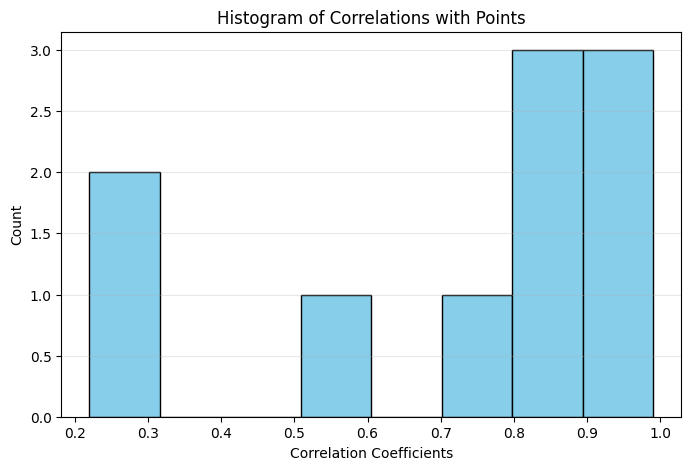

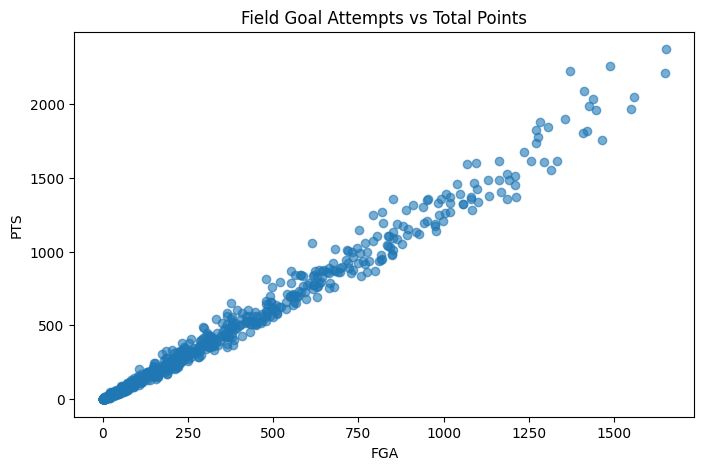

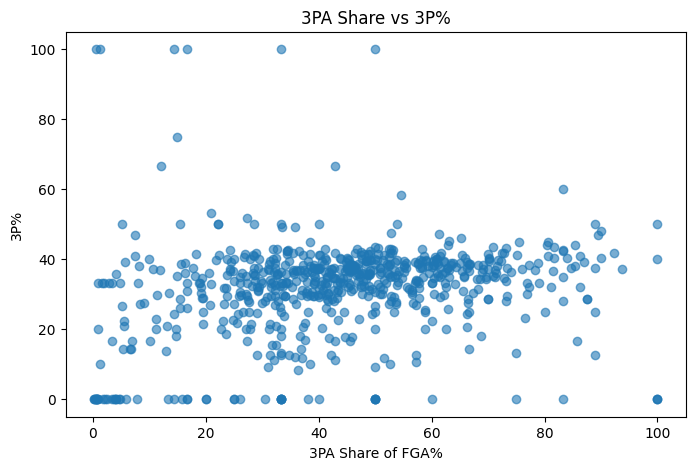

In [12]:
# Conduct exploratory and statistical analyses to uncover meaningful patterns or relationships. (Ben)
import matplotlib.pyplot as plt

# Loading raw totals data
df = pd.read_csv("nba_2024_totals.csv")

# Converting analysis columns to numeric
analysis_cols = ['PTS', '3P','3PA','FG','FGA','TRB','AST','STL','BLK','TOV','MP','G']
for col in analysis_cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that became invalid after conversion and reset index after cleaning
df = df.dropna(subset=analysis_cols).reset_index(drop=True)

df['PTS_per_game'] = df['PTS'] / df['G']
df['FG_pct'] = np.where(df['FGA'] > 0, df['FG'] / df['FGA'] * 100, np.nan)
df['ThreePT_pct'] = np.where(df['3PA'] > 0, df['3P'] / df['3PA'] * 100, np.nan)
df['ThreePA_share'] = np.where(df['FGA'] > 0, df['3PA'] / df['FGA'] * 100, np.nan)
df['AST_to_TOV'] = np.where(df['TOV'] > 0, df['AST'] / df['TOV'] * 100, np.nan)
df['Reb_per_game'] = df['TRB'] / df['G']

# Descriptive Statistics
summary = df[['PTS', 'PTS_per_game','FG_pct','ThreePT_pct','ThreePA_share','AST_to_TOV','Reb_per_game']].describe().round(2)
print("Descriptive Statistics:")
print(summary)

# Top scorers and outliers
top_scorers = df.nlargest(10, 'PTS')[['Player','Team','PTS','PTS_per_game','3P','3PA','ThreePT_pct']]
print('\nTop 10 Scorers:')
print(top_scorers)

q1 = df['PTS'].quantile(0.25)
q3 = df['PTS'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df['PTS'] < lower) | (df['PTS'] > upper)][['Player','Team','PTS']]
print('\nOutliers:')
print(outliers.head(15))

# Correlation analysis
corr_cols = ['PTS', 'MP','FGA','3PA','FG_pct','ThreePT_pct','AST','TRB','TOV','STL','BLK']
corr_df = df[corr_cols].corr(numeric_only=True).round(2)
print('\nCorrelation Matrix:')
print(corr_df)

# Average of total points per player and average points per game by player
print(f"\nAverage Total Points Per Player: {df['PTS'].mean():.1f}")
print(f"Average Points Per Game: {df['PTS_per_game'].mean():.2f}")

# A histogram of points
plt.figure(figsize=(8, 5))
plt.hist(df['PTS'], bins=25, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Points')
plt.xlabel('Points')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# A histogram of correlations with points
corr_vals = corr_df['PTS'].drop('PTS')
plt.figure(figsize=(8, 5))
plt.hist(corr_vals, bins=8, color='skyblue', edgecolor='black')
plt.title('Histogram of Correlations with Points')
plt.xlabel('Correlation Coefficients')
plt.ylabel('Count')
plt.grid(axis='y',alpha=0.3)
plt.show()

# A scatterplot of attempts vs points
plt.figure(figsize=(8, 5))
plt.scatter(df['FGA'], df['PTS'], alpha=0.6)
plt.title('Field Goal Attempts vs Total Points')
plt.xlabel('FGA')
plt.ylabel('PTS')
plt.show()

# A scatterplot of 3PA share vs three pointer percentage
plt.figure(figsize=(8, 5))
plt.scatter(df['ThreePA_share'], df['ThreePT_pct'], alpha=0.6)
plt.title('3PA Share vs 3P%')
plt.xlabel('3PA Share of FGA%')
plt.ylabel('3P%')
plt.show()



In [ ]:
#Summary statistics for important variables (e.g., averages, ranges, counts) (Jada)



In [ ]:
#Tell a coherent and compelling story: What question are you exploring? What did you find? Why does it matter?
